#### 고정코호트 추가 분석 pre6m

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

In [2]:
import os
import pandas as pd

VIDEO_PATH = "data/merged_videos_final.csv"   # 필요하면 수정

print("cwd:", os.getcwd())
print("exists:", os.path.exists(VIDEO_PATH))

df0 = pd.read_csv(VIDEO_PATH, low_memory=False)
print("raw shape:", df0.shape)
print("columns:", df0.columns.tolist())
df0.head()

cwd: /Users/haewon/Downloads/유투브 데이터
exists: True
raw shape: (628146, 15)
columns: ['video_id', 'channel_id', 'published_at', 'video_title', 'video_description', 'video_tags', 'duration_sec', 'view_count', 'like_count', 'is_ai_cover', 'week_start_date', 'weeks_from_policy1', 'weeks_from_policy2', 'search_window_start', 'collected_at_utc']


,video_id,channel_id,published_at,video_title,video_description,video_tags,duration_sec,view_count,like_count,is_ai_cover,week_start_date,weeks_from_policy1,weeks_from_policy2,search_window_start,collected_at_utc
0,--3m-wH7xVo,UC-DadGUHxVxgs_gwadyf5VQ,2024-01-23T13:14:28Z,KANGEN BAND_ TENTANG JEN (TENTANG KEKASIHNYA) ...,#kangenband #karaokehits #karaoke \n\nSawer yu...,kangen band karaoke | karaoke pop Indonesia | ...,318.0,585911,2085.0,0,2024-01-22,-7.86,-77.00,2024-01-19T00:00:00Z,2026-04-12T17:01:13.372151+00:00
1,--8hdkEhVO0,UCZO_SjK_cZHbR8ePQwHTxEQ,2023-10-07T12:29:25Z,BTS Jimin Hindi AI Cover - Tum Hi Ho,#bts #jimin #btsaicover #btsaicover #bts #taeh...,NaN,268.0,12395,447.0,1,2023-10-02,-23.29,-92.43,2023-10-06T00:00:00Z,2026-04-12T17:01:13.372151+00:00
2,--Gsy8rmw3I,UCaGjNXckDVvMa_kCCQGfoKw,2025-01-13T16:45:39Z,Sanam Re {Taehyung AI }🍂| Sanam Re in Taehyung...,~~✨Taehyung AI voice cover song✨~~\n:\n:\n:\n:...,bts ai cover | ai cover | bts | bts ai | black...,325.0,1570889,26587.0,1,2025-01-13,43.00,-26.14,2025-01-10T00:00:00Z,2026-04-12T17:01:13.372151+00:00
3,--Zd4iRSAwM,UC-HPVjsGX6kmx9FXmBmf_5A,2024-01-02T11:58:18Z,「AI COVER」TXT - MR. VAMPIRE (original by ITZY),"ai models by :\nyj - neoculture,\nhk, bg - hwa...",txt | tomorrowxtogether | tomorrow x together ...,174.0,14063,747.0,1,2024-01-01,-10.86,-80.00,2023-12-29T00:00:00Z,2026-04-12T17:01:13.372151+00:00
4,-09A-WFUVtc,UCciWHiZfVbF-ylV4KCIKqyg,2024-10-22T15:17:24Z,[AI COVER] • Furina (Genshin Impact) - Karena ...,🔸 Furina - Karena kamu (Geisha)🔸\n\n\nThank yo...,NaN,233.0,15837,435.0,1,2024-10-21,31.14,-38.00,2024-10-18T00:00:00Z,2026-04-12T17:01:13.372151+00:00


In [2]:
# =========================
# 0. 설정
# ======================
VIDEO_PATH = "data/merged_videos_final.csv"
POLICY1_ANNOUNCE = pd.Timestamp("2023-11-14")
POLICY1_DATE = pd.Timestamp("2024-03-18")

# 그래프 기간 제한을 원하면 사용
PLOT_START = pd.Timestamp("2023-08-01")
PLOT_END   = None   # 예: pd.Timestamp("2025-08-31")

In [3]:
# =========================
# 1. 데이터 로드
# =========================
df = pd.read_csv(VIDEO_PATH, low_memory=False)

# 기본 정리
df["video_id"] = df["video_id"].astype(str).str.strip()
df["channel_id"] = df["channel_id"].astype(str).str.strip()

# 날짜 처리
df["published_at"] = pd.to_datetime(df["published_at"], errors="coerce", utc=True)
df["week_start_date"] = pd.to_datetime(df["week_start_date"], errors="coerce")

# AI cover만 유지
df["is_ai_cover"] = pd.to_numeric(df["is_ai_cover"], errors="coerce")
df = df[df["is_ai_cover"] == 1].copy()

# 핵심 결측 제거
df = df.dropna(subset=["video_id", "channel_id", "published_at", "week_start_date"]).copy()

# 혹시 merge 후 중복이 남아있다면 video_id 기준 제거
df = df.sort_values(["video_id", "published_at"]).drop_duplicates(subset=["video_id"], keep="first").copy()

# 기간 제한
if PLOT_START is not None:
    df = df[df["week_start_date"] >= PLOT_START].copy()
if PLOT_END is not None:
    df = df[df["week_start_date"] <= PLOT_END].copy()

print("rows:", len(df))
print("unique videos:", df["video_id"].nunique())
print("unique channels:", df["channel_id"].nunique())

rows: 143643
unique videos: 143643
unique channels: 4351


In [4]:
# =========================
# 2. fixed cohort 정의
# =========================
# pre-announcement 이전에 업로드한 채널 = fixed cohort
fixed_channels = set(
    df.loc[df["published_at"].dt.tz_convert(None) < POLICY1_ANNOUNCE, "channel_id"]
    .dropna()
    .unique()
)

print("fixed cohort channels:", len(fixed_channels))

df["is_fixed_cohort"] = df["channel_id"].isin(fixed_channels)

fixed cohort channels: 1177


In [5]:
# =========================
# 3. 주간 집계 함수
# =========================
def weekly_metrics(input_df, date_col="week_start_date"):
    weekly = (
        input_df.groupby(date_col)
        .agg(
            uploads=("video_id", "nunique"),
            active_channels=("channel_id", "nunique")
        )
        .reset_index()
        .sort_values(date_col)
    )
    return weekly

weekly_all = weekly_metrics(df)
weekly_fixed = weekly_metrics(df[df["is_fixed_cohort"]].copy())
weekly_nonfixed = weekly_metrics(df[~df["is_fixed_cohort"]].copy())

# 전체 주차 인덱스로 맞추기
all_weeks = pd.DataFrame({
    "week_start_date": pd.date_range(
        start=df["week_start_date"].min(),
        end=df["week_start_date"].max(),
        freq="W-MON"
    )
})

def align_weeks(weekly_df):
    out = all_weeks.merge(weekly_df, on="week_start_date", how="left")
    out["uploads"] = out["uploads"].fillna(0).astype(int)
    out["active_channels"] = out["active_channels"].fillna(0).astype(int)
    return out

weekly_all = align_weeks(weekly_all)
weekly_fixed = align_weeks(weekly_fixed)
weekly_nonfixed = align_weeks(weekly_nonfixed)

In [6]:
# =========================
# 4. sanity check
# =========================
# fixed + nonfixed가 전체와 거의 일치해야 정상
check = weekly_all[["week_start_date", "uploads", "active_channels"]].copy()
check = check.rename(columns={"uploads": "uploads_all", "active_channels": "active_all"})
check = check.merge(
    weekly_fixed[["week_start_date", "uploads", "active_channels"]].rename(
        columns={"uploads": "uploads_fixed", "active_channels": "active_fixed"}
    ),
    on="week_start_date",
    how="left"
)
check = check.merge(
    weekly_nonfixed[["week_start_date", "uploads", "active_channels"]].rename(
        columns={"uploads": "uploads_nonfixed", "active_channels": "active_nonfixed"}
    ),
    on="week_start_date",
    how="left"
)

check["uploads_sum"] = check["uploads_fixed"] + check["uploads_nonfixed"]
check["active_sum"] = check["active_fixed"] + check["active_nonfixed"]

print("uploads mismatch weeks:", (check["uploads_all"] != check["uploads_sum"]).sum())
print("active mismatch weeks:", (check["active_all"] != check["active_sum"]).sum())

uploads mismatch weeks: 0
active mismatch weeks: 0


In [7]:
# =========================
# 5. 그래프 함수
# =========================
def add_policy_lines(ax):
    ax.axvline(POLICY1_ANNOUNCE, linestyle="--", linewidth=1)
    ax.axvline(POLICY1_DATE, linestyle="--", linewidth=1)
    ymax = ax.get_ylim()[1]
    ax.text(POLICY1_ANNOUNCE, ymax * 0.95, "Pre-announcement\n2023-11-14",
            ha="left", va="top", fontsize=10)
    ax.text(POLICY1_DATE, ymax * 0.95, "Policy\n2024-03-18",
            ha="left", va="top", fontsize=10)

def plot_single(series_df, y_col, title, y_label):
    plt.figure(figsize=(14, 5))
    plt.plot(series_df["week_start_date"], series_df[y_col], linewidth=2)
    plt.title(title)
    plt.xlabel("Week")
    plt.ylabel(y_label)
    add_policy_lines(plt.gca())
    plt.tight_layout()
    plt.show()

def plot_compare(df1, df2, y_col, label1, label2, title, y_label):
    plt.figure(figsize=(14, 5))
    plt.plot(df1["week_start_date"], df1[y_col], linewidth=2, label=label1)
    plt.plot(df2["week_start_date"], df2[y_col], linewidth=2, label=label2)
    plt.title(title)
    plt.xlabel("Week")
    plt.ylabel(y_label)
    plt.legend()
    add_policy_lines(plt.gca())
    plt.tight_layout()
    plt.show()

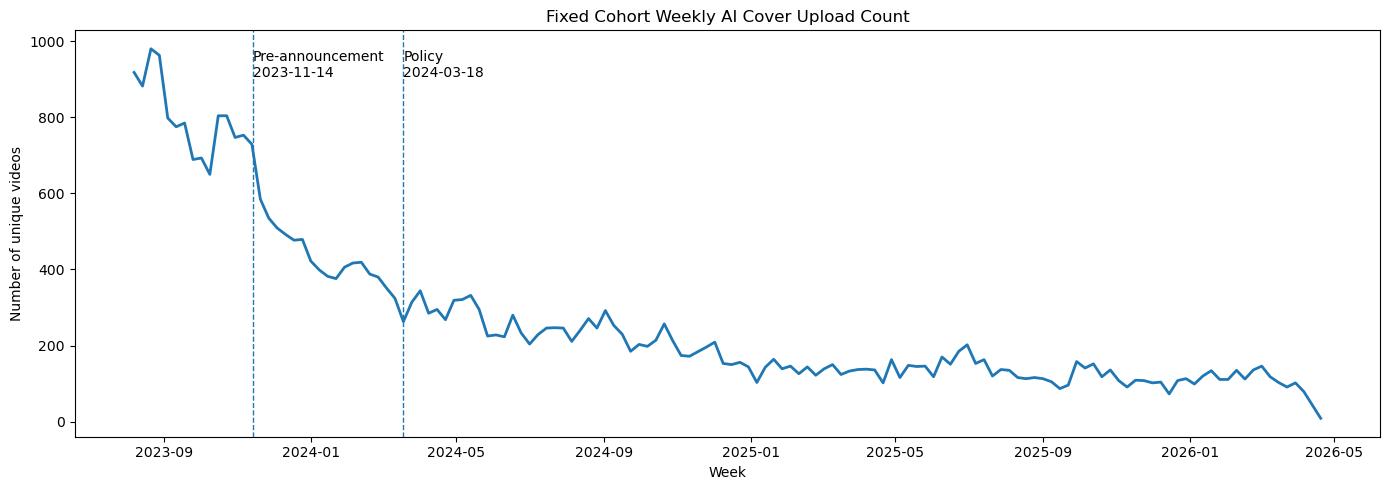

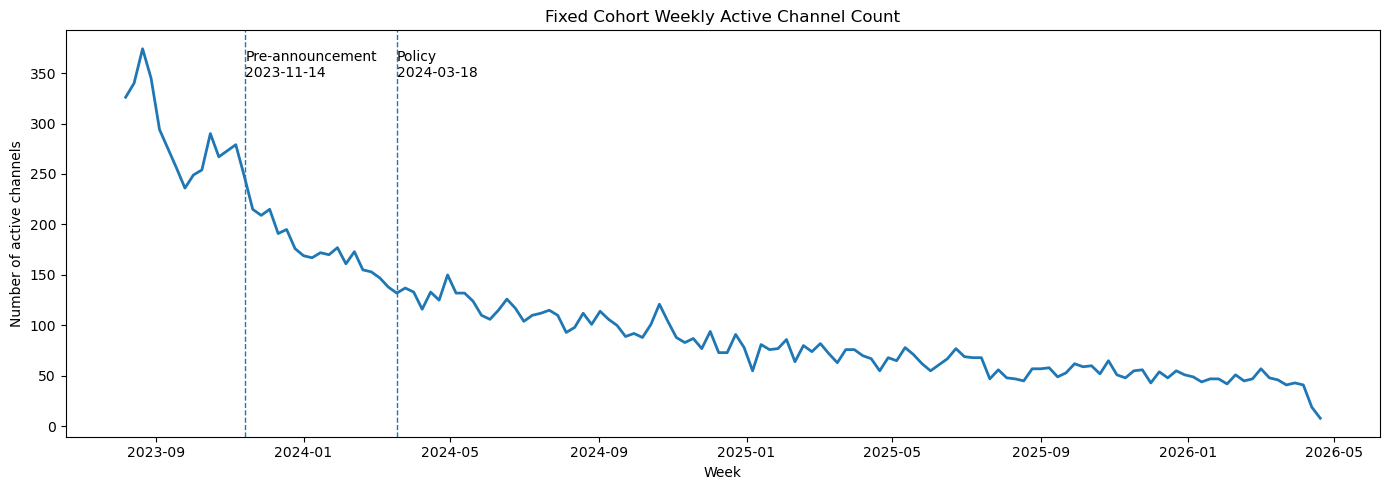

In [8]:
# =========================
# 6. fixed cohort 그래프
# =========================
plot_single(
    weekly_fixed,
    y_col="uploads",
    title="Fixed Cohort Weekly AI Cover Upload Count",
    y_label="Number of unique videos"
)

plot_single(
    weekly_fixed,
    y_col="active_channels",
    title="Fixed Cohort Weekly Active Channel Count",
    y_label="Number of active channels"
)

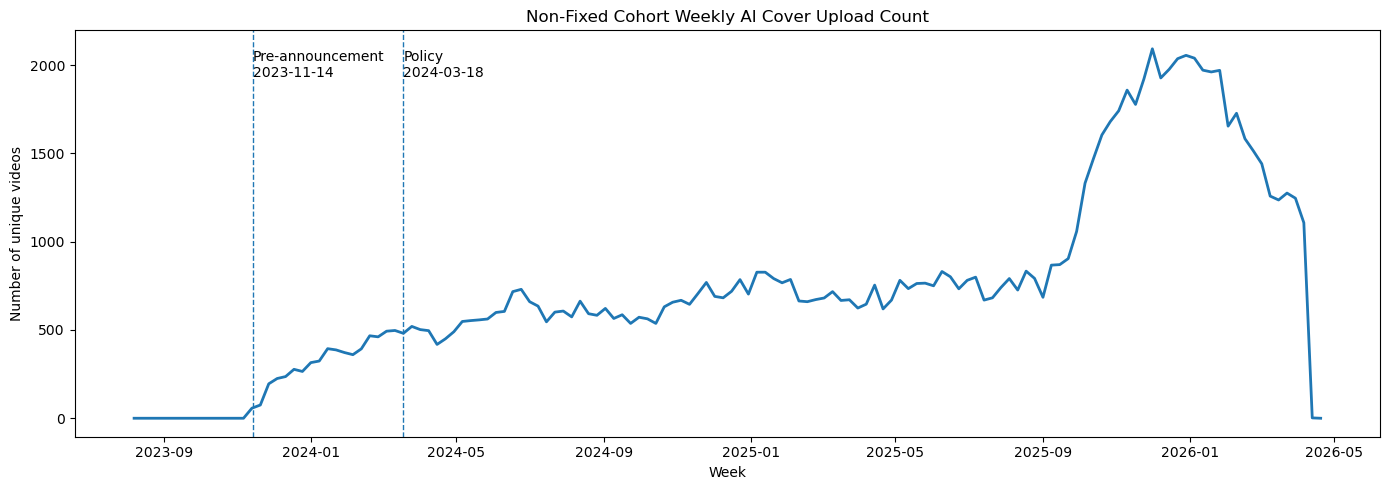

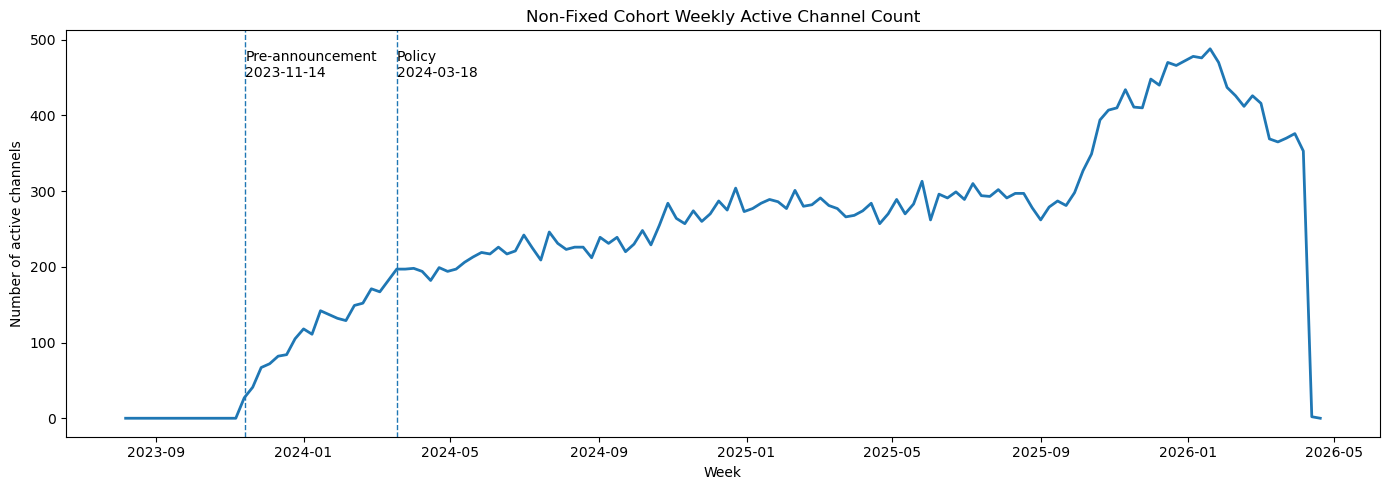

In [9]:
# =========================
# 7. fixed cohort 제외 그래프
# =========================
plot_single(
    weekly_nonfixed,
    y_col="uploads",
    title="Non-Fixed Cohort Weekly AI Cover Upload Count",
    y_label="Number of unique videos"
)

plot_single(
    weekly_nonfixed,
    y_col="active_channels",
    title="Non-Fixed Cohort Weekly Active Channel Count",
    y_label="Number of active channels"
)


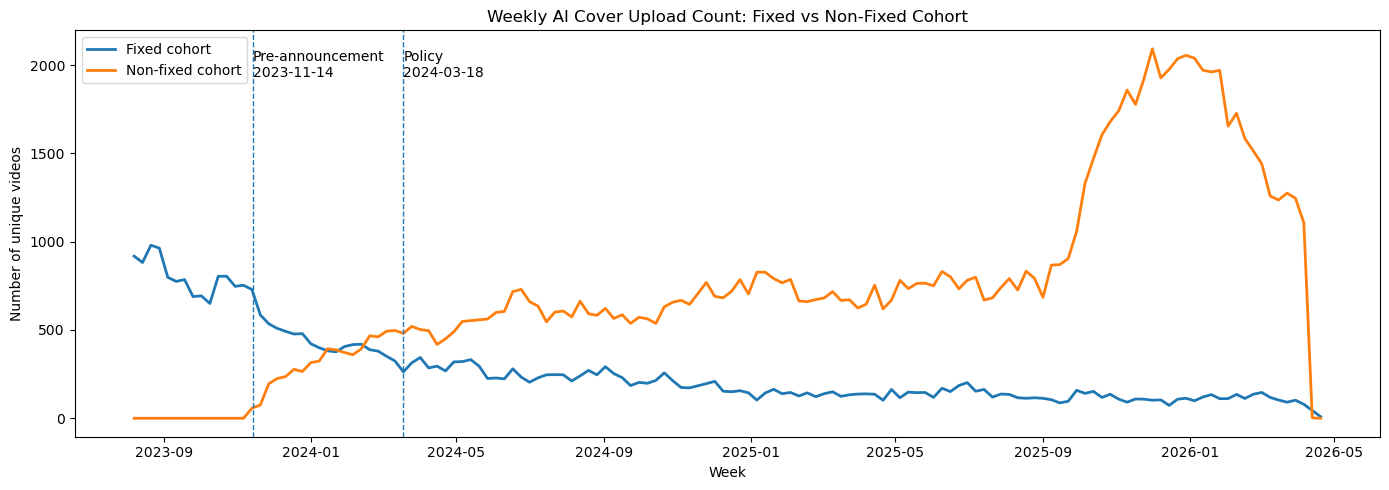

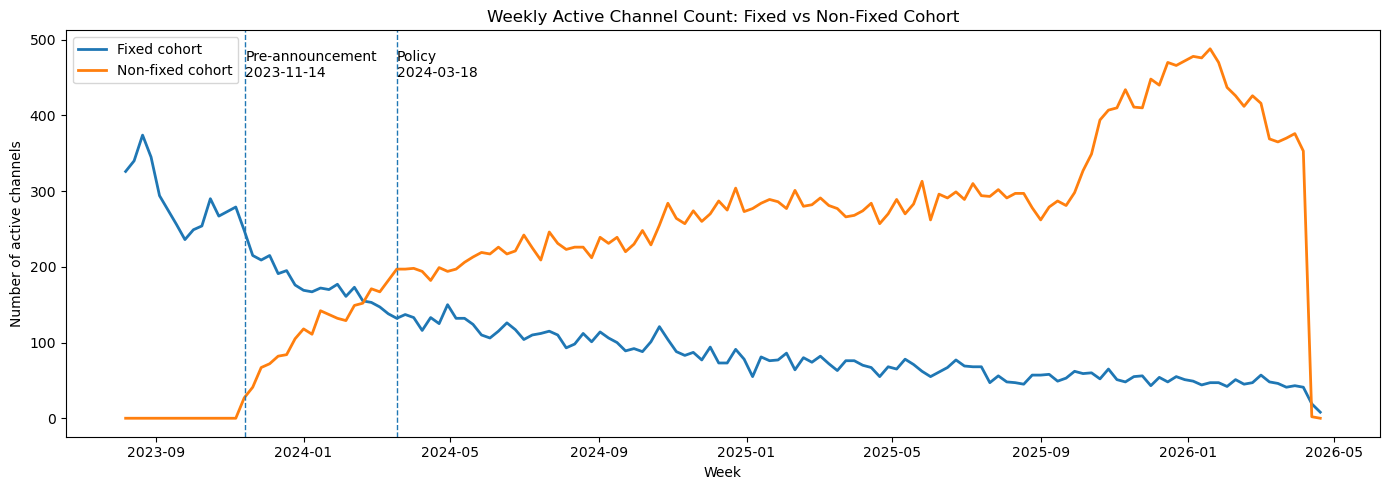

In [10]:
# =========================
# 8. 비교 그래프
# =========================
plot_compare(
    weekly_fixed, weekly_nonfixed,
    y_col="uploads",
    label1="Fixed cohort",
    label2="Non-fixed cohort",
    title="Weekly AI Cover Upload Count: Fixed vs Non-Fixed Cohort",
    y_label="Number of unique videos"
)

plot_compare(
    weekly_fixed, weekly_nonfixed,
    y_col="active_channels",
    label1="Fixed cohort",
    label2="Non-fixed cohort",
    title="Weekly Active Channel Count: Fixed vs Non-Fixed Cohort",
    y_label="Number of active channels"
)

In [11]:
# =========================
# 9. 표도 보고 싶으면
# =========================
cohort_table = weekly_all[["week_start_date"]].copy()
cohort_table = cohort_table.merge(
    weekly_fixed.rename(columns={
        "uploads": "fixed_uploads",
        "active_channels": "fixed_active_channels"
    }),
    on="week_start_date",
    how="left"
)
cohort_table = cohort_table.merge(
    weekly_nonfixed.rename(columns={
        "uploads": "nonfixed_uploads",
        "active_channels": "nonfixed_active_channels"
    }),
    on="week_start_date",
    how="left"
)

cohort_table = cohort_table.fillna(0)
cohort_table.head(20)

,week_start_date,fixed_uploads,fixed_active_channels,nonfixed_uploads,nonfixed_active_channels
0,2023-08-07,918,326,0,0
1,2023-08-14,882,340,0,0
2,2023-08-21,980,374,0,0
3,2023-08-28,963,345,0,0
4,2023-09-04,798,294,0,0
5,2023-09-11,775,275,0,0
6,2023-09-18,785,256,0,0
7,2023-09-25,689,236,0,0
8,2023-10-02,693,249,0,0
9,2023-10-09,650,254,0,0
